## Heterogeneous RBCs via Deep Multi-Agent Reinforcement Learning - tutorial

Code to replicate the results in [this paper](https://arxiv.org/abs/2510.12272) using bench-marl


In [44]:
import os
from benchmarl.algorithms import IppoConfig, IsacConfig
from benchmarl.experiment import Experiment, ExperimentConfig
from benchmarl.models.mlp import MlpConfig
from marlbc_task import RBCTask


## Classic RBC, representative-agent model

In [45]:
experiment_config = ExperimentConfig.get_from_yaml()
from dataclasses import asdict
for k, v in asdict(experiment_config).items():
    print(f"{k}: {v}")

sampling_device: cpu
train_device: cpu
buffer_device: cpu
share_policy_params: True
prefer_continuous_actions: True
collect_with_grad: False
parallel_collection: False
gamma: 0.99
lr: 5e-05
adam_eps: 1e-06
adam_extra_kwargs: {}
clip_grad_norm: True
clip_grad_val: 5
soft_target_update: True
polyak_tau: 0.005
hard_target_update_frequency: 5
exploration_eps_init: 0.8
exploration_eps_end: 0.01
exploration_anneal_frames: None
max_n_iters: None
max_n_frames: 3000000
on_policy_collected_frames_per_batch: 6000
on_policy_n_envs_per_worker: 10
on_policy_n_minibatch_iters: 45
on_policy_minibatch_size: 400
off_policy_collected_frames_per_batch: 6000
off_policy_n_envs_per_worker: 10
off_policy_n_optimizer_steps: 1000
off_policy_train_batch_size: 128
off_policy_memory_size: 1000000
off_policy_init_random_frames: 0
off_policy_use_prioritized_replay_buffer: False
off_policy_prb_alpha: 0.6
off_policy_prb_beta: 0.4
evaluation: True
render: True
evaluation_interval: 120000
evaluation_episodes: 10
evaluat

In [46]:
task = RBCTask.KL.get_task(config={
    "n_agents":  1,             # number of household agents
    "obs_space": ["capital"],  # observations each agent receives
    "num_iters": 200,           # episode length
    "delta": 1.0,             # capital depreciation rate
})


# ── Experiment config ─────────────────────────────────────────────────────────
experiment_config.gamma                        = 0.95    # "beta" in economics
experiment_config.max_n_frames                  = 4000 * 25   # total training frames
experiment_config.on_policy_collected_frames_per_batch = 4000
experiment_config.on_policy_n_envs_per_worker   = 4
experiment_config.on_policy_n_minibatch_iters   = 45
experiment_config.on_policy_minibatch_size       = 400

experiment_config.evaluation                    = True
experiment_config.evaluation_interval           = 4000
experiment_config.evaluation_episodes           = 1
experiment_config.evaluation_deterministic_actions = True
experiment_config.render                        = False

experiment_config.loggers                       = ["tensorboard"]
experiment_config.create_json                   = True


results_dir = "results_marlbc"
os.makedirs(results_dir, exist_ok=True)
experiment_config.save_folder = results_dir

# ── Algorithm ─────────────────────────────────────────────────────────────────
algorithm_config = IppoConfig.get_from_yaml()

# ── Models (actor + critic both MLP) ──────────────────────────────────────────
model_config        = MlpConfig.get_from_yaml()
critic_model_config = MlpConfig.get_from_yaml()


In [47]:
experiment = Experiment(
    task=task,
    algorithm_config=algorithm_config,
    model_config=model_config,
    critic_model_config=critic_model_config,
    seed=0,
    config=experiment_config,
)
experiment.run()

  0%|          | 0/25 [00:00<?, ?it/s]

2026-03-25 12:49:54,638 [torchrl][INFO]    Initialized LazyTensorStorage with torch.Size([4000]) shape [END]


mean return = -807.4673461914062: 100%|██████████| 25/25 [03:11<00:00,  7.68s/it] 


In [48]:
# ── Resume training from where it stopped ────────────────────────────────────
# experiment.run() closes the collector and logger when it finishes.
# Re-initialize them before running again (trained weights are preserved).

additional_frames = 4000 * 10   # e.g. 10 more iterations
experiment.config.max_n_frames = experiment.total_frames + additional_frames

experiment._setup_task()       # re-opens test_env (needed for evaluation)
experiment._setup_collector()  # recreates the data collector
experiment._setup_logger()     # reconnects logging

experiment.run()


mean return = -751.8016357421875: 100%|██████████| 35/35 [01:24<00:00,  8.44s/it]


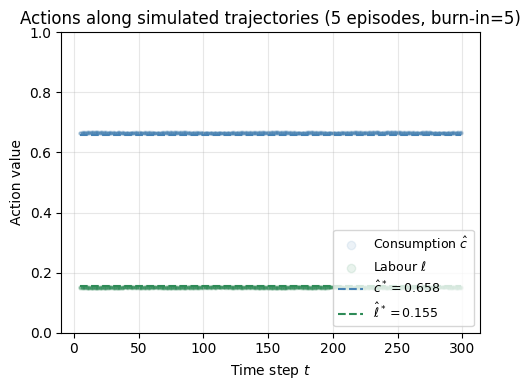

In [49]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from tensordict import TensorDict
from torchrl.envs.utils import set_exploration_type, ExplorationType
from marlbc_simulators import RBCSimulator_KL
from marlbc_env import RBCParallelEnv

group    = list(experiment.group_map.keys())[0]
n_agents = len(experiment.group_map[group])
n_episodes = 5
burn_in = 5

# Analytical steady-state values
alpha_ss, beta_ss, b_ss = 0.36, 0.95, 5.0
c_star = 1.0 - alpha_ss * beta_ss
l_star = alpha_ss / (b_ss * (1.0 - (1.0 - alpha_ss) * beta_ss) + alpha_ss)

experiment.policy.eval()

c_all, l_all, t_all = [], [], []

for _ in range(n_episodes):
    sim    = RBCSimulator_KL(n_agents=1, delta=1.0)
    pz_env = RBCParallelEnv(simulator=sim, obs_space=["capital"], num_iters=300)
    obs_dict, _ = pz_env.reset()

    c_traj, l_traj = [], []
    while pz_env.agents:
        k_val = float(obs_dict["h_0"][0])
        obs_tensor = torch.tensor([[[k_val]]], dtype=torch.float32)
        obs_td = TensorDict(
            {group: {"observation": obs_tensor.expand(1, n_agents, 1)}},
            batch_size=[1], device="cpu",
        )

        with torch.no_grad(), set_exploration_type(ExplorationType.DETERMINISTIC):
            out_td = experiment.policy(obs_td)

        raw = out_td[group]["action"][0, 0, :].numpy()
        obs_dict, _, _, _, _ = pz_env.step({"h_0": raw})

        c_traj.append((raw[0] + 1.0) / 2.0)
        l_traj.append((raw[1] + 1.0) / 2.0)

    c_traj = np.array(c_traj)[burn_in:]
    l_traj = np.array(l_traj)[burn_in:]
    t = np.arange(burn_in, burn_in + len(c_traj))
    c_all.append(c_traj); l_all.append(l_traj); t_all.append(t)

c_all = np.concatenate(c_all)
l_all = np.concatenate(l_all)
t_all = np.concatenate(t_all)

fig, ax = plt.subplots(figsize=(5, 4))

ax.scatter(t_all, c_all, s=4, alpha=0.1, color="steelblue", label=r"Consumption $\hat{c}$")
ax.scatter(t_all, l_all, s=4, alpha=0.1, color="seagreen",  label=r"Labour $\ell$")

t_range = [t_all.min(), t_all.max()]
ax.plot(t_range, [c_star, c_star], color="steelblue", lw=1.5, ls="--",
        label=f"$\\hat{{c}}^* = {c_star:.3f}$")
ax.plot(t_range, [l_star, l_star], color="seagreen",  lw=1.5, ls="--",
        label=f"$\\hat{{\\ell}}^* = {l_star:.3f}$")

ax.set_xlabel("Time step $t$")
ax.set_ylabel("Action value")
ax.set_title(f"Actions along simulated trajectories ({n_episodes} episodes, burn-in={burn_in})")
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9, markerscale=3, loc="lower right")

plt.tight_layout()
plt.show()


## Mean-field, Krusell-Smith model

In [50]:
# Switch to RBCTask.KS for the Krusell-Smith variant.
task = RBCTask.KS.get_task(config={
    "n_agents":  20,             # number of household agents
    "obs_space": ["capital", 
                "mean_capital", 
                "aggregate_state",
                "idiosyncratic_state"],  # observations each agent receives
    "num_iters": 200,           # episode length
    "delta": 0.025,             # capital depreciation rate
})

# ── Experiment config ─────────────────────────────────────────────────────────
experiment_config = ExperimentConfig.get_from_yaml()
experiment_config.gamma                         = 0.95
experiment_config.max_n_frames                  = 80_000   # total training frames
experiment_config.on_policy_collected_frames_per_batch = 3200
experiment_config.on_policy_n_envs_per_worker   = 4
experiment_config.on_policy_n_minibatch_iters   = 20#45
experiment_config.on_policy_minibatch_size      = 200#400
 
# experiment_config.off_policy_collected_frames_per_batch = 4_000
# experiment_config.off_policy_n_envs_per_worker = 4
# experiment_config.off_policy_n_optimizer_steps = 450
# experiment_config.off_policy_train_batch_size = 128
# experiment_config.off_policy_memory_size = 12_000

experiment_config.evaluation                    = True
experiment_config.evaluation_interval           = 3200
experiment_config.evaluation_episodes           = 1
experiment_config.evaluation_deterministic_actions = True
experiment_config.render                        = False

experiment_config.loggers                       = ["tensorboard"]
experiment_config.create_json                   = True

results_dir = "results_marlbc"
os.makedirs(results_dir, exist_ok=True)
experiment_config.save_folder = results_dir

# ── Algorithm ─────────────────────────────────────────────────────────────────
algorithm_config = IppoConfig.get_from_yaml()
# algorithm_config = IsacConfig.get_from_yaml()

# ── Models (actor + critic both MLP) ──────────────────────────────────────────
model_config        = MlpConfig.get_from_yaml()
critic_model_config = MlpConfig.get_from_yaml()


In [ ]:
# ── Experiment ────────────────────────────────────────────────────────────────

experiment = Experiment(
    task=task,
    algorithm_config=algorithm_config,
    model_config=model_config,
    critic_model_config=critic_model_config,
    seed=0,
    config=experiment_config,
)

experiment.run()


  0%|          | 0/25 [00:00<?, ?it/s]

2026-03-25 12:54:57,512 [torchrl][INFO]    Initialized LazyTensorStorage with torch.Size([3200]) shape [END]


mean return = 139.0363006591797:  64%|██████▍   | 16/25 [05:00<03:04, 20.53s/it] 

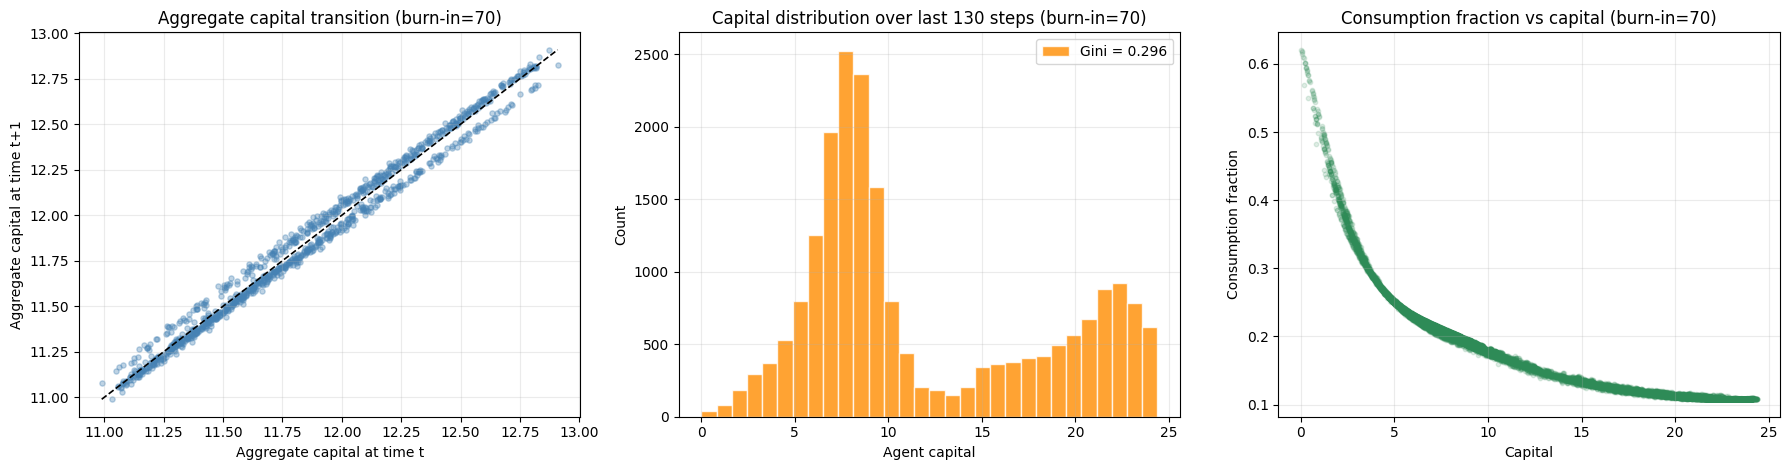

In [42]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from tensordict import TensorDict
from torchrl.envs.utils import set_exploration_type, ExplorationType
from marlbc_simulators import RBCSimulator_KS
from marlbc_env import RBCParallelEnv

group = list(experiment.group_map.keys())[0]
n_agents = len(experiment.group_map[group])
obs_space = task.config["obs_space"]
capital_idx = obs_space.index("capital")

n_eval_episodes = 8
horizon = task.config["num_iters"]
burn_in = 70          # steps to discard at the start of each episode
last_n_steps = 130

experiment.policy.eval()

agg_k_t = []
agg_k_tp1 = []
all_capitals = []
all_capitals_tp1 = []
all_c_fracs = []
last_window_capitals = []

for _ in range(n_eval_episodes):
    sim = RBCSimulator_KS(n_agents=n_agents, delta=task.config["delta"])
    pz_env = RBCParallelEnv(
        simulator=sim,
        obs_space=obs_space,
        num_iters=horizon,
    )
    obs_dict, _ = pz_env.reset()

    step = 0
    episode_capitals = []

    while pz_env.agents:
        agents = pz_env.agents[:]
        capital_t = np.array([obs_dict[agent][capital_idx] for agent in agents], dtype=float)
        obs_tensor = torch.tensor(
            [[obs_dict[agent] for agent in agents]],
            dtype=torch.float32,
        )
        obs_td = TensorDict(
            {group: {"observation": obs_tensor}},
            batch_size=[1],
            device="cpu",
        )

        with torch.no_grad(), set_exploration_type(ExplorationType.DETERMINISTIC):
            out_td = experiment.policy(obs_td)

        raw_actions = out_td[group]["action"][0].cpu().numpy()
        c_fracs = (raw_actions[:, 0] + 1.0) / 2.0
        action_dict = {agent: raw_actions[idx] for idx, agent in enumerate(agents)}

        next_obs_dict, _, _, _, _ = pz_env.step(action_dict)
        capital_tp1 = np.array([next_obs_dict[agent][capital_idx] for agent in agents], dtype=float)

        if step >= burn_in:
            agg_k_t.append(capital_t.mean())
            agg_k_tp1.append(capital_tp1.mean())
            all_capitals.append(capital_t)
            all_capitals_tp1.append(capital_tp1)
            all_c_fracs.append(c_fracs)
            episode_capitals.append(capital_tp1)

        obs_dict = next_obs_dict
        step += 1

    if episode_capitals:
        last_window_capitals.extend(episode_capitals[-last_n_steps:])

agg_k_t = np.concatenate([np.atleast_1d(x) for x in agg_k_t])
agg_k_tp1 = np.concatenate([np.atleast_1d(x) for x in agg_k_tp1])
all_capitals = np.concatenate(all_capitals)
all_c_fracs = np.concatenate(all_c_fracs)
last_window_capitals = np.concatenate(last_window_capitals)

def gini(x):
    x = np.sort(np.abs(x))
    n = len(x)
    return (2 * np.sum(np.arange(1, n + 1) * x) / (n * x.sum()) - (n + 1) / n)

gini_val = gini(last_window_capitals)

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))

axes[0].scatter(agg_k_t, agg_k_tp1, s=14, alpha=0.35, color="steelblue")
min_k = min(agg_k_t.min(), agg_k_tp1.min())
max_k = max(agg_k_t.max(), agg_k_tp1.max())
axes[0].plot([min_k, max_k], [min_k, max_k], ls="--", lw=1.2, color="black")
axes[0].set_xlabel("Aggregate capital at time t")
axes[0].set_ylabel("Aggregate capital at time t+1")
axes[0].set_title(f"Aggregate capital transition (burn-in={burn_in})")
axes[0].grid(True, alpha=0.25)

axes[1].hist(last_window_capitals, bins=30, color="darkorange", alpha=0.8, edgecolor="white",
             label=f"Gini = {gini_val:.3f}")
axes[1].set_xlabel("Agent capital")
axes[1].set_ylabel("Count")
axes[1].set_title(f"Capital distribution over last {last_n_steps} steps (burn-in={burn_in})")
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.25)

axes[2].scatter(all_capitals, all_c_fracs, s=10, alpha=0.15, color="seagreen")
axes[2].set_xlabel("Capital")
axes[2].set_ylabel("Consumption fraction")
axes[2].set_title(f"Consumption fraction vs capital (burn-in={burn_in})")
axes[2].grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

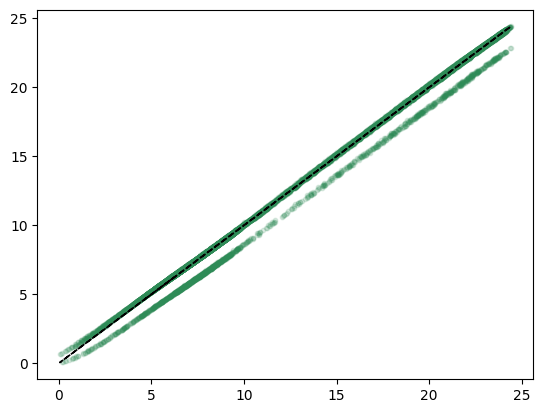

In [33]:
plt.scatter(all_capitals, all_capitals_tp1, s=10, alpha=0.15, color="seagreen")
plt.plot(all_capitals, all_capitals, ls="--", lw=1.2, color="black")